# Imports

In [1]:
import os, gc, json, pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel,
    CLIPTextModel
)

from transformers import logging
logging.set_verbosity_error()


from captum.attr import IntegratedGradients, Saliency
from scipy.stats import spearmanr
import quantus

import matplotlib.pyplot as plt

from paths import (
    DATASETS_DIR,
    text_xai_dir,
    text_artifact_dir,
    text_eval_dir,
    ensure_dirs
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

CURRENT_DATASET = "Flickr8k"
ensure_dirs()


/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda


# Load Dataset

In [2]:
df = pd.read_pickle(os.path.join(DATASETS_DIR, f"df_{CURRENT_DATASET}.pkl"))

# Flickr8k has 5 captions per image → take first
#TEXTS = [caps[0] for caps in df["captions"].tolist()]
#TEXTS = TEXTS[:50]

TEXTS = [cap for caps in df["captions"] for cap in caps]



# Dataset Class

In [3]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_len=64):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0)
        }


# Text Models

In [4]:
class TextWrapper(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(
        self,
        input_ids=None,
        inputs_embeds=None,
        attention_mask=None,
        output_hidden_states=False,
        output_attentions=False,
        return_dict=True
    ):

        out = self.backbone(
            input_ids=input_ids,
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            output_hidden_states=output_hidden_states,
            output_attentions=output_attentions,
            return_dict=return_dict
        )

        cls = out.last_hidden_state[:, 0, :]
        logits = self.head(cls)
        return logits


In [5]:
def load_bert(device):
    tok = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    ).to(device).eval()
    return model, tok, model.bert

def load_roberta(device):
    tok = AutoTokenizer.from_pretrained("roberta-base")
    model = AutoModelForSequenceClassification.from_pretrained(
        "roberta-base",
        num_labels=2
    ).to(device).eval()
    return model, tok, model.roberta

def load_gpt2(device):
    tok = AutoTokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token
    model = AutoModelForSequenceClassification.from_pretrained(
        "gpt2",
        num_labels=2,
        pad_token_id=tok.pad_token_id
    ).to(device).eval()
    return model, tok, model.transformer

# Explanations Captum

In [6]:
class EmbeddingWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, embeddings, attention_mask=None):
        out = self.model(
            inputs_embeds=embeddings,
            attention_mask=attention_mask
        )
        return out.logits


In [7]:
def explain_ig(model, batch, target):
    emb_layer = model.get_input_embeddings()
    input_embeds = emb_layer(batch["input_ids"])

    wrapper = EmbeddingWrapper(model)
    ig = IntegratedGradients(wrapper)

    attr = ig.attribute(
        input_embeds,
        additional_forward_args=(batch["attention_mask"],),
        target=target
    )
    return attr.norm(dim=-1)


In [13]:
def explain_saliency(model, batch, target):
    emb_layer = model.get_input_embeddings()
    embeds = emb_layer(batch["input_ids"])

    wrapper = EmbeddingWrapper(model)
    sal = Saliency(wrapper)

    attr = sal.attribute(
        embeds,
        additional_forward_args=(batch["attention_mask"],),
        target=target
    )
    return attr.norm(dim=-1)


In [8]:
def flatten_attr(attr):
    a = attr.detach().cpu().numpy().squeeze()
    return (a - a.min()) / (a.max() - a.min() + 1e-8)

def entropy_text(attr):
    a = flatten_attr(attr)
    a = a / (a.sum() + 1e-8)
    return -np.sum(a * np.log(a + 1e-8))


In [9]:
def extract_text_artifacts(model_name, model, batch, idx):
    root = text_artifact_dir(CURRENT_DATASET, model_name)
    os.makedirs(root, exist_ok=True)

    with torch.no_grad():
        # Call encoder directly (old notebook logic)
        if model_name == "BERT":
            out = model.bert(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                output_hidden_states=True,
                return_dict=True
            )
        elif model_name == "RoBERTa":
            out = model.roberta(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                output_hidden_states=True,
                return_dict=True
            )
        elif model_name == "GPT2":
            out = model.transformer(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                output_hidden_states=True,
                return_dict=True
            )

    cls = out.last_hidden_state[:, 0, :]
    torch.save(cls.cpu(), f"{root}/cls_{idx}.pt")

    tokens = out.last_hidden_state[:, 1:, :]
    torch.save(tokens.cpu(), f"{root}/tokens_{idx}.pt")


# Execution

In [ ]:
TEXT_MODELS = {
    "BERT": load_bert,
    "RoBERTa": load_roberta,
    "GPT2": load_gpt2,
}

In [ ]:


all_records = []

for model_name, loader_fn in TEXT_MODELS.items():
    print(f"\n=== Running {model_name} ===")

    model, tok, backbone = loader_fn(device)
    dataset = TextDataset(TEXTS, tok)
    loader = torch.utils.data.DataLoader(dataset, batch_size=1)

    xai_root = text_xai_dir(CURRENT_DATASET, model_name)
    os.makedirs(xai_root, exist_ok=True)

    model_records = []

    for idx, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(batch["input_ids"], attention_mask=batch["attention_mask"])
        logits = out.logits
        label = logits.argmax(dim=1).item()

        ig_attr = explain_ig(model, batch, label)
        sal_attr = explain_saliency(model, batch, label)

        torch.save(ig_attr.cpu(), f"{xai_root}/IG_{idx}.pt")
        torch.save(sal_attr.cpu(), f"{xai_root}/Saliency_{idx}.pt")

        extract_text_artifacts(model_name, model, batch, idx)

        model_records.append({
            "idx": idx,
            "label": label,
            "IG": ig_attr.cpu(),
            "Saliency": sal_attr.cpu(),
            "input_ids": batch["input_ids"].cpu()
        })

    with open(f"{xai_root}/captum_records.pkl", "wb") as f:
        pickle.dump(model_records, f)

    all_records.append({ "model": model_name, "records": model_records })



=== Running BERT ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Running RoBERTa ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Running GPT2 ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:


all_records = []

for model_name, loader_fn in TEXT_MODELS.items():
    print(f"\n=== Running {model_name} ===")

    model, tok, backbone = loader_fn(device)
    dataset = TextDataset(TEXTS, tok)
    loader = torch.utils.data.DataLoader(dataset, batch_size=1)

    xai_root = text_xai_dir(CURRENT_DATASET, model_name)
    os.makedirs(xai_root, exist_ok=True)

    model_records = []

    for idx, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        out = model(batch["input_ids"], attention_mask=batch["attention_mask"])
        logits = out.logits
        label = logits.argmax(dim=1).item()

        ig_attr = explain_ig(model, batch, label)
        #sal_attr = explain_saliency(model, batch, label)

        torch.save(ig_attr.cpu(), f"{xai_root}/Flickr8k/IG_{idx}.pt")
        #torch.save(sal_attr.cpu(), f"{xai_root}/Saliency_{idx}.pt")

        extract_text_artifacts(model_name, model, batch, idx)

        model_records.append({
            "idx": idx,
            "label": label,
            "IG": ig_attr.cpu(),
            #"Saliency": sal_attr.cpu(),
            "input_ids": batch["input_ids"].cpu()
        })

    with open(f"{xai_root}/captum_records_all_gpt2.pkl", "wb") as f:
        pickle.dump(model_records, f)

    all_records.append({ "model": model_name, "records": model_records })



=== Running GPT2 ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [18]:
with open(os.path.join(text_xai_dir(CURRENT_DATASET, model_name), "captum_records_all_5.pkl"), "wb") as f:
    pickle.dump(all_records, f)

all_records[0]

{'model': 'BERT',
 'records': [{'idx': 0,
   'label': 1,
   'IG': tensor([[0.0189, 0.0062, 0.0098, 0.0062, 0.0052, 0.0093, 0.0103, 0.0071, 0.0120,
            0.0070, 0.0069, 0.0083, 0.0050, 0.0094, 0.0050, 0.0060, 0.0118, 0.0098,
            0.0117, 0.0322, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
            0.0000]], grad_fn=<ToCopyBackward0>),
   'input_ids': tensor([[ 101, 1037, 2775, 1999, 1037, 5061, 4377, 2003, 8218, 2039, 1037, 2275,
            1997, 5108, 1999, 2019, 4443, 2126, 1012,  102,    0,    0,    0,    0,
               0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
               0,    0,    0,    0

In [19]:
print(os.path.join(text_xai_dir(CURRENT_DATASET, "GPT2"), "captum_records_all_5.pkl"))

TFE_Data/Attributions/Text/Flickr8k/GPT2/captum_records_all_5.pkl


In [40]:
gpt2_records = all_records[0]["records"]
print("GPT2:", len(gpt2_records))


GPT2: 40455


In [41]:
import os, pickle

# Paths
bert_path = os.path.join(text_xai_dir(CURRENT_DATASET, "BERT"), "captum_records_all_5.pkl")
roberta_path = os.path.join(text_xai_dir(CURRENT_DATASET, "RoBERTa"), "captum_records_all_5.pkl")
gpt2_path = os.path.join(text_xai_dir(CURRENT_DATASET, "GPT2"), "captum_records_all_5.pkl")

# Load BERT (wrapped)
with open(bert_path, "rb") as f:
    bert_data = pickle.load(f)
if len(bert_records) == 40456:
    bert_records = bert_records[1:]

# Load RoBERTa (flat)
with open(roberta_path, "rb") as f:
    roberta_records = pickle.load(f)

# Load GPT‑2 (flat)
gpt2_records = all_records[0]["records"]

# Combine normalized blocks
combined = [
    {"model": "BERT", "records": bert_records},
    {"model": "RoBERTa", "records": roberta_records},
    {"model": "GPT2", "records": gpt2_records},
]

# Save unified file
final_path = os.path.join(text_xai_dir(CURRENT_DATASET, ), "captum_records_all_5_final.pkl")
with open(final_path, "wb") as f:
    pickle.dump(combined, f)

# Verify
with open(final_path, "rb") as f:
    data = pickle.load(f)
print("Blocks:", len(data))
for block in data:
    print(block["model"], len(block["records"]))


Blocks: 3
BERT 40455
RoBERTa 40455
GPT2 40455


In [ ]:
final_path = os.path.join(text_xai_dir(CURRENT_DATASET), "captum_records_all.pkl")

with open(final_path, "wb") as f:
    pickle.dump(combined, f)


In [ ]:
with open(final_path, "rb") as f:
    data = pickle.load(f)

print("Blocks:", len(data))
for block in data:
    print(block["model"], len(block["records"]))


# Metrics

In [163]:
def get_valid_mask_token(tok):
    if tok.mask_token_id is not None:
        return tok.mask_token_id
    return tok.eos_token_id   # GPT‑2 fallback


In [164]:
def rankcorr_text(model, tok, batch, label, attr):
    model_cpu = model.to("cpu").eval()

    ids  = batch["input_ids"].clone().cpu()
    attn = batch["attention_mask"].clone().cpu()

    seq_len = ids.shape[1]
    mask_token_id = get_valid_mask_token(tok)

    # Build batch: original + masked versions
    ids_batch  = ids.repeat(seq_len + 1, 1)
    attn_batch = attn.repeat(seq_len + 1, 1)

    # Mask each token
    for i in range(seq_len):
        ids_batch[i + 1, i] = mask_token_id

    # Forward once
    with torch.no_grad():
        logits = model_cpu(ids_batch, attention_mask=attn_batch).logits.softmax(1)

    base = logits[0, label].item()
    masked_scores = logits[1:, label].numpy()

    impacts = base - masked_scores
    attrs = flatten_attr(attr)

    corr, _ = spearmanr(attrs, impacts)
    return corr


In [165]:
def stability_text(model, batch, label, attr):
    model_cpu = model.to("cpu").eval()

    emb_layer = model_cpu.get_input_embeddings()
    input_embeds = emb_layer(batch["input_ids"].cpu())

    wrapper = EmbeddingWrapper(model_cpu)
    ig = IntegratedGradients(wrapper)

    # simple augmentation
    embeds_aug = input_embeds.clone()
    if embeds_aug.shape[1] > 3:
        embeds_aug[0,1] = embeds_aug[0,2]

    attr_aug = ig.attribute(
        embeds_aug,
        additional_forward_args=(batch["attention_mask"].cpu(),),
        target=label
    ).norm(dim=-1)

    a1 = flatten_attr(attr)
    a2 = flatten_attr(attr_aug)

    return float(np.dot(a1, a2) / (np.linalg.norm(a1)*np.linalg.norm(a2) + 1e-8))


In [170]:
def reduce_attr_for_quantus_text(attr):
    return attr.detach().cpu().numpy().reshape(1, -1)

def text_to_signal(model, input_ids):
    device = next(model.parameters()).device
    emb = model.get_input_embeddings()(input_ids.to(device))
    signal = emb.norm(dim=-1)
    return signal.unsqueeze(0).detach().cpu().numpy()   # FIX

class QuantusTextWrapper(nn.Module):
    def __init__(self, model, input_ids):
        super().__init__()
        self.model = model
        self.emb = model.get_input_embeddings()
        self.input_ids = input_ids.to(next(model.parameters()).device)

    def forward(self, x):
        x = np.array(x).astype(np.float32).reshape(1, -1)
        x = torch.from_numpy(x).to(self.input_ids.device)

        base = self.emb(self.input_ids)
        norm = base.norm(dim=-1, keepdim=True)
        unit = base / (norm + 1e-8)

        emb = unit * x.unsqueeze(-1)
        return self.model(inputs_embeds=emb).logits


In [174]:
import nltk
from nltk.corpus import wordnet as wn
nltk.download("wordnet", quiet=True)

def synonym_paraphrase(tokens):
    new_tokens = []
    for tok in tokens:
        syns = wn.synsets(tok)
        if syns:
            lemmas = syns[0].lemma_names()
            if len(lemmas) > 1:
                new_tokens.append(lemmas[1].replace("_", " "))
                continue
        new_tokens.append(tok)
    return new_tokens


In [181]:
def compute_ig(model, tok, text_ids, label):
    emb_layer = model.get_input_embeddings()
    device = next(model.parameters()).device
    text_ids = text_ids.to(device)              # ⭐ FIX
    input_embeds = emb_layer(text_ids)

    wrapper = EmbeddingWrapper(model)
    ig = IntegratedGradients(wrapper)

    attr = ig.attribute(
        input_embeds,
        additional_forward_args=((text_ids != 0).long(),),
        target=label
    )
    return attr.norm(dim=-1)


In [179]:
def paraphrase_robustness(model, tok, batch, label, attr):
    # 1. Decode tokens
    tokens = tok.convert_ids_to_tokens(batch["input_ids"][0])

    # 2. Paraphrase tokens
    para_tokens = synonym_paraphrase(tokens)

    # 3. Re-tokenize paraphrased text
    para_text = tok.convert_tokens_to_string(para_tokens)
    para_ids = tok(para_text, return_tensors="pt").input_ids

    # 4. Compute IG for paraphrased text
    attr_para = compute_ig(model, tok, para_ids, label)

    # 5. Compare original vs paraphrased IG
    a1 = attr.squeeze().detach().cpu().numpy()
    a2 = attr_para.squeeze().detach().cpu().numpy()

    # Pad to same length if needed
    L = min(len(a1), len(a2))
    a1, a2 = a1[:L], a2[:L]

    # Cosine similarity = robustness
    sim = np.dot(a1, a2) / (np.linalg.norm(a1)*np.linalg.norm(a2) + 1e-8)
    return float(sim)


In [168]:
def evaluate_quantus_text(model, input_ids, label, attr):
    signal = text_to_signal(model, input_ids)
    a_np = reduce_attr_for_quantus_text(attr)
    y_np = np.array([label])

    wrapper = QuantusTextWrapper(model, input_ids).eval()

    metrics = [
        quantus.FaithfulnessCorrelation(
            subset_size=5,
            nr_runs=10,
            similarity_func=quantus.similarity_func.correlation_spearman
        ),
        quantus.Complexity(),
        quantus.Sparseness()
    ]

    results = {}
    for m in metrics:
        try:
            results[m.__class__.__name__] = float(m(
                model=wrapper,
                x_batch=signal,
                a_batch=a_np,
                y_batch=y_np
            )[0])
        except Exception as e:
            results[m.__class__.__name__] = np.nan

    return results


# Execution

In [182]:
text_results = []

for entry in all_records:
    model_name = entry["model"]
    model, tok, backbone = TEXT_MODELS[model_name](device)

    print(f"Evaluating {model_name}...")
    model_scores = []

    for item in entry["records"]:
        label = item["label"]
        attr  = item["IG"]
        ids   = item["input_ids"]

        batch = {
            "input_ids": ids,
            "attention_mask": (ids != 0).long()
        }

        # --- Quantus metrics ---
        quantus_scores = evaluate_quantus_text(model, ids, label, attr)

        # --- Paraphrase robustness ---
        para_score = paraphrase_robustness(model, tok, batch, label, attr)

        # --- Build final score row ---
        scores = {
            "faithfulness": quantus_scores.get("FaithfulnessCorrelation", np.nan),
            "complexity":   quantus_scores.get("Complexity", np.nan),
            "sparsity":     quantus_scores.get("Sparseness", np.nan),
            "paraphrase_robustness": para_score
        }

        model_scores.append(scores)

    text_results.append({
        "model": model_name,
        "scores": model_scores
    })


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating BERT...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/home/aysel/tfe/.venv/lib/python3.12/site-packages/quantus/helpers/warn.py:257: UserWarning: The settings for perturbing input e.g., 'perturb_func' didn't cause change in input. Reconsider the paramet

Evaluating RoBERTa...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Evaluating GPT2...


In [183]:
rows = []

for entry in text_results:
    model = entry["model"]
    for s in entry["scores"]:
        rows.append([
            model,
            s["faithfulness"],
            s["complexity"],
            s["sparsity"],
            s["paraphrase_robustness"]
        ])

df = pd.DataFrame(rows, columns=[
    "model", "faithfulness", "complexity", "sparsity", "paraphrase_robustness"
])

df = df.groupby("model").mean().reset_index()
df.to_csv("text_explainability_results.csv", index=False)
df


,model,faithfulness,complexity,sparsity,paraphrase_robustness
0,BERT,-0.585570,2.428059,0.852363,0.626716
1,GPT2,0.049312,2.354109,0.868472,0.766264
2,RoBERTa,-0.324661,2.509093,0.839590,0.598739


In [1]:
import pandas as pd

df_text = pd.read_csv(
    "TFE_Data/Evaluations/Unimodal/text/Flickr8k/model_selection/text_explainability_normalized.csv"
)

print(df_text.head())

     Model  Faithfulness  Complexity  Compactness  Paraphrase Robustness
0     BERT      0.281769    0.507614     0.480796               0.397854
1     GPT2      0.741505    0.727985     0.738118               0.757787
2  RoBERTa      0.470509    0.266026     0.277007               0.326036


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os

def radar_subplot_text(df, save_path=None):

    metrics = [
        "Faithfulness",
        "Complexity",
        "Compactness",
        "Paraphrase Robustness"
    ]

    models = df["Model"].unique()

    angles = np.linspace(
        0,
        2 * np.pi,
        len(metrics),
        endpoint=False
    ).tolist()

    angles += angles[:1]

    fig, axes = plt.subplots(
        1,
        len(models),
        subplot_kw=dict(polar=True),
        figsize=(4 * len(models), 8)
    )

    if len(models) == 1:
        axes = [axes]

    labels = [
        "Faithfulness",
        "Complexity",
        "Compactness",
        "Paraphrase Robustness"
    ]

    for ax, model in zip(axes, models):

        row = df[df["Model"] == model].iloc[0]

        values = row[metrics].values.astype(float)
        values = np.concatenate((values, [values[0]]))

        ax.plot(angles, values, linewidth=2)
        ax.fill(angles, values, alpha=0.25)

        ax.set_title(model, fontsize=12)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=9)

        # rotate labels
        for i, (label, angle) in enumerate(
            zip(ax.get_xticklabels(), angles[:-1])
        ):

            angle_deg = np.degrees(angle)

            label.set_rotation(angle_deg)
            label.set_horizontalalignment("center")

            if labels[i] in ["Faithfulness", "Compactness"]:
                ax.tick_params(axis='x', pad=22)

        ax.set_ylim(0, 1)

    plt.tight_layout()

    if save_path:

        os.makedirs(save_path, exist_ok=True)

        plt.savefig(
            os.path.join(
                save_path,
                "radar_subplot_all_models.png"
            ),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os

def radar_text_model(
    df,
    model_name,
    save_path=None
):

    metrics = [
        "Faithfulness",
        "Complexity",
        "Compactness",
        "Paraphrase Robustness"
    ]

    labels = [
        "Faithfulness",
        "Complexity",
        "Compactness",
        "Paraphrase Robustness"
    ]

    # -----------------------------------
    # Extract model row
    # -----------------------------------
    row = df[df["Model"] == model_name]

    if len(row) == 0:
        print(f"Model '{model_name}' not found.")
        return

    row = row.iloc[0]

    values = row[metrics].values.astype(float)

    # close radar polygon
    values = np.concatenate((values, [values[0]]))

    angles = np.linspace(
        0,
        2 * np.pi,
        len(metrics),
        endpoint=False
    ).tolist()

    angles += angles[:1]

    # -----------------------------------
    # Figure
    # -----------------------------------
    fig, ax = plt.subplots(
        figsize=(7, 7),
        subplot_kw=dict(polar=True)
    )

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_title(
        model_name,
        fontsize=14,
        pad=20
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)

    # -----------------------------------
    # Rotate labels
    # -----------------------------------
    for i, (label, angle) in enumerate(
        zip(ax.get_xticklabels(), angles[:-1])
    ):

        angle_deg = np.degrees(angle)

        label.set_rotation(angle_deg)
        label.set_horizontalalignment("center")

        if labels[i] in [
            "Faithfulness",
            "Compactness"
        ]:
            ax.tick_params(axis='x', pad=22)

    ax.set_ylim(0, 1)

    plt.tight_layout()

    # -----------------------------------
    # Save
    # -----------------------------------
    if save_path:

        os.makedirs(save_path, exist_ok=True)

        filename = (
            model_name
            + "_radar.png"
        )

        plt.savefig(
            os.path.join(save_path, filename),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

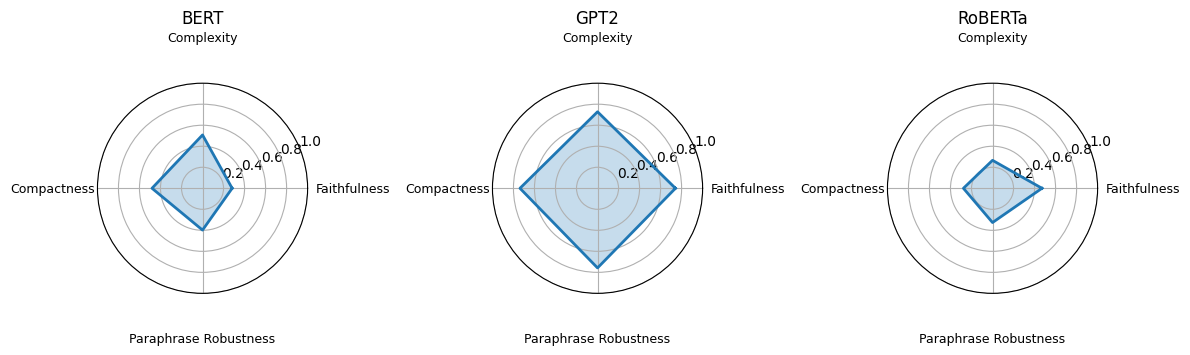

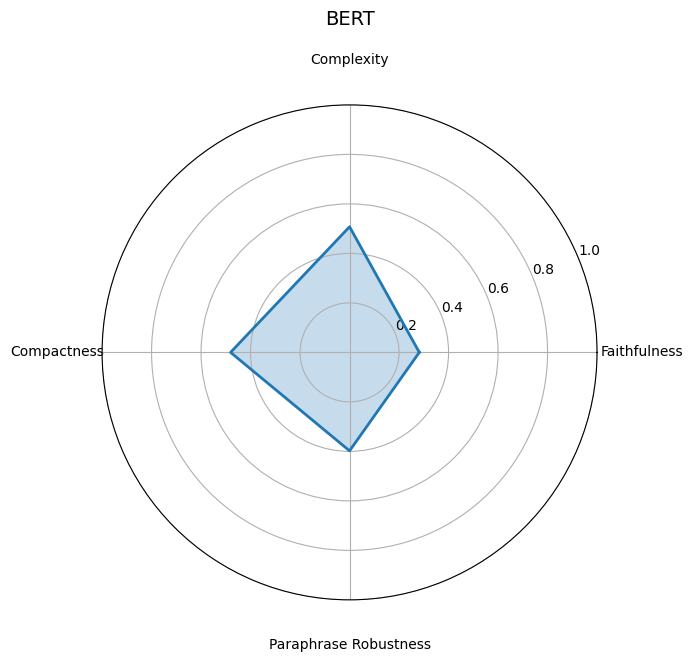

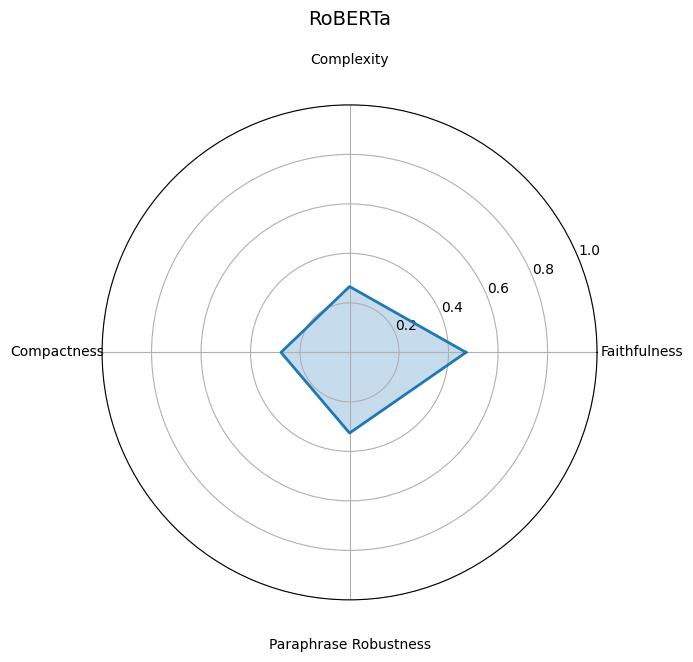

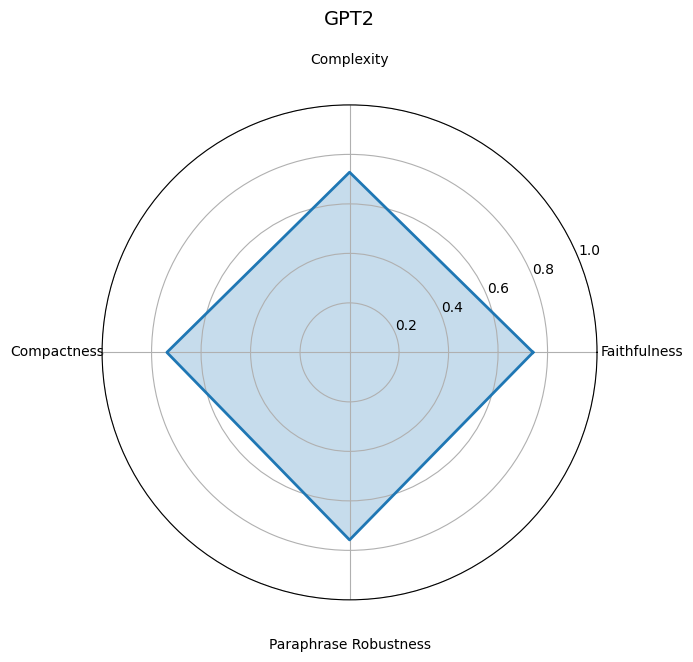

In [25]:
radar_subplot_text(
    df_text, "/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots/"
)

radar_text_model(df_text, "BERT", "/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots")
radar_text_model(df_text, "RoBERTa", "/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots")
radar_text_model(df_text, "GPT2", "/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots")

# Visualisation

In [201]:
def clean_token(tok):
    # Remove GPT‑2 / RoBERTa BPE space marker
    if tok.startswith("Ġ"):
        return tok[1:]
    if tok.startswith("Ċ"):
        return tok[1:]
    return tok


In [56]:
def visualize_tokens(tokenizer, input_ids, attributions, title="Token Attribution"):
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())

    # Reduce attributions to 1D
    scores = attributions.squeeze()
    if scores.ndim > 1:
        scores = scores.sum(axis=-1)
    scores = scores.detach().cpu().numpy()

    # Normalize
    scores = scores / (np.max(np.abs(scores)) + 1e-8)

    # ⭐ FIX: sanitize NaN / inf
    scores = np.nan_to_num(scores, nan=0.0, posinf=1.0, neginf=-1.0)

    special = set(tokenizer.all_special_tokens)
    filtered_tokens, filtered_scores = [], []

    for tok, score in zip(tokens, scores):
        if tok in special or tok.strip() == "":
            continue
        tok = tok.replace("Ġ", "").replace("Ċ", "")
        filtered_tokens.append(tok)
        filtered_scores.append(score)

    # Adaptive figure width
    fig_width = min(max(len(filtered_tokens) * 0.5, 6), 18)
    fig, ax = plt.subplots(figsize=(fig_width, 1.8))
    ax.axis("off")

    renderer = fig.canvas.get_renderer()
    token_widths = []
    for tok in filtered_tokens:
        t = ax.text(0, 0, tok, fontsize=11)
        bb = t.get_window_extent(renderer=renderer)
        token_widths.append(bb.width / fig.dpi / fig.get_size_inches()[0])
        t.remove()

    total_width = sum(token_widths) + 0.01 * (len(filtered_tokens) - 1)
    start_x = max((1 - total_width) / 2, 0.02)
    x, y = start_x, 0.5

    for tok, score, width in zip(filtered_tokens, filtered_scores, token_widths):
        color = plt.cm.Reds(abs(score))  # now always valid
        ax.text(
            x, y, tok,
            fontsize=11,
            transform=ax.transAxes,
            bbox=dict(facecolor=color, alpha=0.8, edgecolor="black", boxstyle="round,pad=0.25")
        )
        x += width + 0.01

    plt.title(title)
    plt.tight_layout()
    return fig



def visualize_tokens_on_ax(tokenizer, input_ids, attributions, ax, title=""):

    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())

    scores = attributions.squeeze()

    if scores.ndim > 1:
        scores = scores.sum(axis=-1)

    scores = scores.detach().cpu().numpy()
    scores = scores / (np.max(np.abs(scores)) + 1e-8)
    scores = np.nan_to_num(scores, nan=0.0, posinf=1.0, neginf=-1.0)

    special = set(tokenizer.all_special_tokens)

    filtered_tokens, filtered_scores = [], []

    for tok, score in zip(tokens, scores):
        if tok in special or tok.strip() == "":
            continue
        tok = tok.replace("Ġ", "").replace("Ċ", "")
        filtered_tokens.append(tok)
        filtered_scores.append(score)

    ax.axis("off")
    ax.set_title(title)

    x = 0.02
    y = 0.5

    for tok, score in zip(filtered_tokens, filtered_scores):

        color = plt.cm.Reds(abs(score))

        ax.text(
            x, y, tok,
            fontsize=10,
            transform=ax.transAxes,
            bbox=dict(
                facecolor=color,
                alpha=0.8,
                edgecolor="black",
                boxstyle="round,pad=0.25"
            )
        )

        x += 0.02 + 0.01 * len(tok)

In [31]:
import os
import pickle

TEXT_ATTR_PATHS = {
    "BERT": "TFE_Data/Attributions/Text/Flickr8k/BERT/captum_records.pkl",
    "RoBERTa": "TFE_Data/Attributions/Text/Flickr8k/RoBERTa/captum_records.pkl",
    "GPT2": "TFE_Data/Attributions/Text/Flickr8k/GPT2/captum_records.pkl",
}

all_records = []

for model_name, path in TEXT_ATTR_PATHS.items():

    with open(path, "rb") as f:
        records = pickle.load(f)

    all_records.append({
        "model": model_name,
        "records": records
    })

print("Loaded models:", [r["model"] for r in all_records])

Loaded models: ['BERT', 'RoBERTa', 'GPT2']


In [35]:
from scipy.stats import spearmanr
import numpy as np

def flatten_attr(attr):

    x = attr.detach().cpu().numpy()

    x = np.squeeze(x)

    if x.ndim > 1:
        x = x.mean(axis=-1)

    return x.flatten()
def compute_agreement(sample):

    ig  = flatten_attr(sample["IG"])
    sal = flatten_attr(sample["Saliency"])

    corr = spearmanr(ig, sal).correlation

    return {
        "ig_sal": corr
    }

In [46]:
agreement_results = []

for entry in all_records:

    model_name = entry["model"]

    for sample in entry["records"]:

        scores = compute_agreement(sample)

        scores["model"] = model_name
        scores["idx"] = sample["idx"]

        agreement_results.append(scores)

print("Computed:", len(agreement_results))

Computed: 150


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

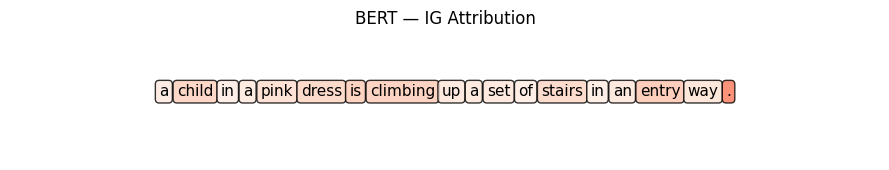

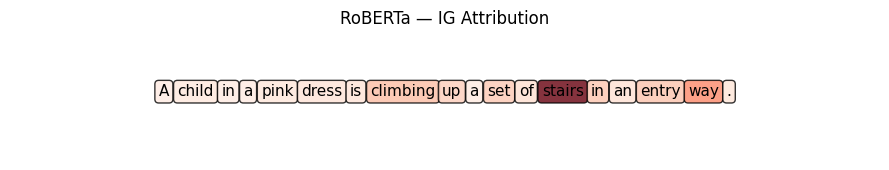

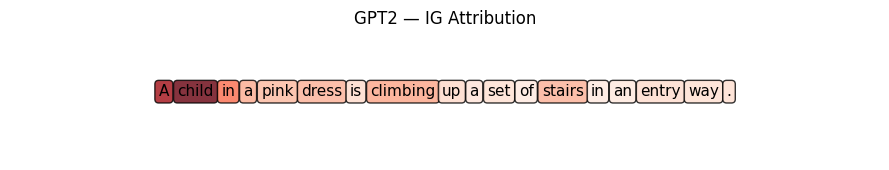

In [47]:
for entry in all_records:
    model_name = entry["model"]

    model, tok, backbone = TEXT_MODELS[model_name](device)

    item = entry["records"][0]

    visualize_tokens(
        tok,
        item["input_ids"][0],
        item["IG"][0],
        title=f"{model_name} — IG Attribution"
    )


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

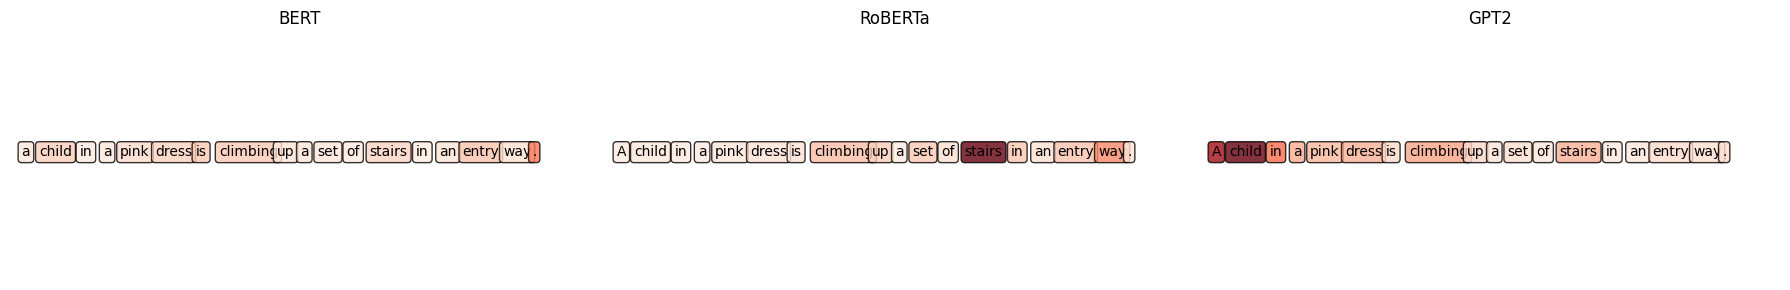

In [57]:
import matplotlib.pyplot as plt

idx = 0  # same sample

fig, axes = plt.subplots(1, 3, figsize=(18, 3))

models = ["BERT", "RoBERTa", "GPT2"]

for ax, model_name in zip(axes, models):

    model, tok, backbone = TEXT_MODELS[model_name](device)

    item = next(
        r for r in all_records
        if r["model"] == model_name
    )["records"][0]

    visualize_tokens_on_ax(
        tok,
        item["input_ids"][0],
        item["IG"][0],
        ax,
        title=model_name
    )

plt.tight_layout()
plt.show()

In [48]:
from scipy.stats import spearmanr

def compute_agreement(sample):

    ig  = flatten_attr(sample["IG"])
    sal = flatten_attr(sample["Saliency"])

    corr = spearmanr(ig, sal).correlation

    return {
        "ig_sal": corr
    }

In [51]:
agreement_results = []

for entry in all_records:

    model_name = entry["model"]

    for sample in entry["records"]:

        scores = compute_agreement(sample)

        scores["model"] = model_name
        scores["idx"] = sample["idx"]

        agreement_results.append(scores)

print("Computed:", len(agreement_results))


df_agreement = pd.DataFrame(agreement_results)

df_agreement

df_avg = (
    df_agreement
    .groupby("model")["ig_sal"]
    .mean()
    .reset_index()
)

print(df_avg)

Computed: 150
     model    ig_sal
0     BERT  0.991140
1     GPT2  0.989491
2  RoBERTa  0.988916
